Test JaxTracer on Hydro Turbulence

Import Libs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

#add path
sys.path.insert(0, '../../../src/')     # import path/to/synthpy

import simulator.config as config
config.jax_init()

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Import domain

In [2]:
columns = ["dims", "rays", "runtime", "legacyRuntime", "domainSize", "raySize", "totalMemory"]
df = pd.DataFrame(columns = columns)

#load hdf
ne, dims, spacing = utilIO.hdf_readin("/rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC/xyz14_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0228")

# ne, dims, spacing = utilIO.hdf_readin("Turb_hdf5_plt_cnt_0050")


print(ne.shape)

'''
# multiply domain to match real size experimental target
multi_x = 0 # get multiplier x
multi_y = 0 # get multiplier y
multi_z = 0 # get multiplier z

for i in range(multi_x):
    ne = np.append(ne, ne, axis = 0)
for j in range(multi_y):
    ne = np.append(ne, ne, axis = 1)
for k in range(multi_z):
    ne = np.append(ne, ne, axis = 2)
'''

dims = ne.shape

extent_x = ((dims[0]*spacing[0].v)/2) * 1e-2
extent_y = ((dims[1]*spacing[1].v)/2) * 1e-2
extent_z = ((dims[2]*spacing[2].v)/2) * 1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 5e7

domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6)

del ne_x
del ne_y
del ne_z
del ne

yt : [INFO     ] 2025-09-02 13:32:24,667 Parameters: current_time              = 2.336596261854855e-07
yt : [INFO     ] 2025-09-02 13:32:24,668 Parameters: domain_dimensions         = [1200  750  500]
yt : [INFO     ] 2025-09-02 13:32:24,668 Parameters: domain_left_edge          = [-0.1  0.   0. ]
yt : [INFO     ] 2025-09-02 13:32:24,669 Parameters: domain_right_edge         = [1.1  0.75 0.5 ]
yt : [INFO     ] 2025-09-02 13:32:24,669 Parameters: cosmological_simulation   = 0


(1200, 750, 500)
[0.012  0.0075 0.005 ]
extent x: 0.006000000000000001
extent y: 0.00375
extent z: 0.0025
dims x: 1200
dims y: 750
dims z: 500



Predicted size in memory of domain: 1.6763806343078613 GB

Memory prior to domain creation:
 - total : 24.0 GB
 - free  : 23.291015625 GB
 - used  : 726.0 MB

Est. ray size in memory: 102.81801223754883 GB
Est. domain memory limit: 10.058283805847168 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 318.51232051849365 GB

ESTIMATE SUGGESTS DOMAIN + RAYS CANNOT FIT IN AVAILABLE MEMORY.
 --> Auto-batching rays based on memory available and domain size estimate...
 --> Can't auto-batch the domain as it is imported (limitation will be resolved in the future)

padded up-to 1200 entries.(1200, 750, 500) --> 
 --> x padded with: 0 nan's
 --> y padded with: 450 nan's
 --> z padded with: 700 nan's

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


Tracing using JaxTracer

9.252329642006494e+25


np.float64(0.0025)

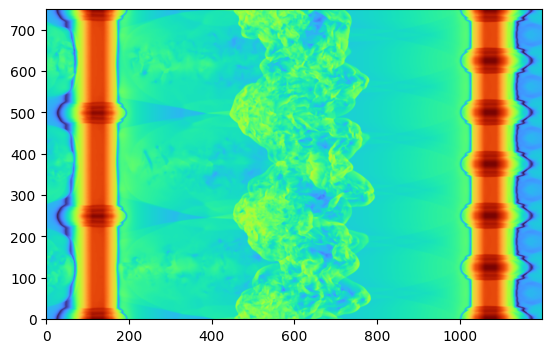

In [3]:
print(domain.ne.T.max())
plt.imshow(domain.ne[:,:,20].T, origin="lower",cmap='turbo', norm="log")
extent_z

In [4]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.05e-3
beam_type      =  "rectangular"

rf, _, duration = p.solve((beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain, probing_extent, verbose = False)


Number of domain batches: 1
Number of ray batches: 14

Est. size in memory of rays (1 = 736 B): 2.4480475187301636 GB
Est. potential size in memory of total rays: 34.27267074584961 GB
 --> Np (total) = 50000000 (in 14 batches) - 3571428 for this batch

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.0025 mm's to the target depth of 0.0025 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0004436969757080078 seconds
Est. size in memory of rays (1 = 736 B): 2.4480475187301636 GB
Est. potential size in memory of total rays: 34.27267074584961 GB
 --> Np (total) = 50000000 (in 14 batches) - 3571428 for this batch

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.0025 mm's to the target depth of 0.0025 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0003991127014160

In [5]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(lwl, rf, focal_plane = -400)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

refractometer = diag.Refractometry(lwl, rf)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)



50000000 rays received, 45930998 incident on the first lens.
 --> 8.139999 % of rays wasted!

rf size expected: [45930998. 45930998.]
rf after clearing nan's: [44194503. 44194503.]

50000000 rays received, 45930998 incident on the first lens.
 --> 8.139999 % of rays wasted!

rf size expected: [45930998. 45930998.]
rf after clearing nan's: [45930979. 45930979.]


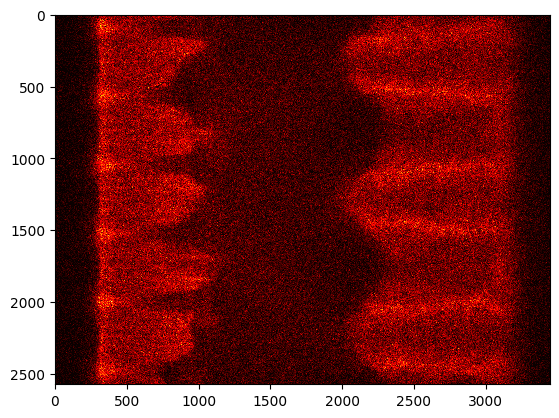

In [6]:
plt.imshow(shadowgrapher.H, cmap = 'hot', interpolation = 'nearest')